> This script is deigned to be used with conda env
> crime_weather_env

Code to explore the crimetology_NS.parquet file.
Data created via combine_crime_ceda_data.py.

## Import modules

In [1]:
from pandas.core.frame import DataFrame
from _duckdb import DuckDBPyConnection
import os
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import plotly.express as px
from IPython.display import Markdown

## Directories, db and Path Setup

In [2]:

cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / "data" / "police_archives"
crime_db: Path = data_dir/'crime_archive.db'


In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

In [4]:
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

## Introspect

In [5]:

# introspect (looks like duckdb parquet requires relative paths)
#file_path: str = os.path.relpath(path=data_dir.joinpath(crime_weather_pq))
query_introspect: str = """DESCRIBE SELECT * 
                           FROM crimetology_NS
                        """ 
con.execute(query=query_introspect).df()

,column_name,column_type,null,key,default,extra
0,Crime ID,VARCHAR,YES,None,None,None
1,Month,VARCHAR,YES,None,None,None
2,Longitude,DOUBLE,YES,None,None,None
3,Latitude,DOUBLE,YES,None,None,None
4,Crime type,VARCHAR,YES,None,None,None
5,tasmax,FLOAT,YES,None,None,None
6,tas,FLOAT,YES,None,None,None
7,groundfrost,FLOAT,YES,None,None,None
8,sun,FLOAT,YES,None,None,None
9,snowLying,FLOAT,YES,None,None,None


In [6]:
# Crimes present
query_crimes_present: str = """SELECT DISTINCT "Crime type"
                               FROM crimetology_NS
                            """
con.execute(query=query_crimes_present).df()

,Crime type
0,Drugs
1,Criminal damage and arson
2,Anti-social behaviour
3,Possession of weapons
4,Other theft
5,Other crime
6,Bicycle theft
7,Shoplifting
8,Robbery
9,Violence and sexual offences


In [7]:
# head
query_head: str = """SELECT *
                     FROM crimetology_NS
                     LIMIT 5
                  """
con.execute(query_head).df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347


## Geography Check

In [8]:
lat_lon_query: str = """SELECT DISTINCT "Latitude",
                                        "Longitude"
                              FROM crimetology_NS
                     """
lat_lons_df: DataFrame = con.execute(lat_lon_query).df()

Note: this needs the VSCode extension Jupyter Notebook Renderers (Microsoft) to plot

In [9]:
fig = px.scatter_map(data_frame=lat_lons_df,
                lat='Latitude',
                lon='Longitude')
fig.update_layout(mapbox_style="open-street-map")
#fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show(config={'staticPlot': True})

In [10]:
#close the figure as plotly is crashing VSCode
fig = None

So, obviously filtereing by *WHERE "Falls within" IN ('Norfolk Constabulary', 'Suffolk Constabulary')* in combine_crime_ceda_data.py has not limited the geographic domain enough. 
Checking the [archives info page](https://data.police.uk/about/) - this pulls data that was provided by the respective constabularies, not necessarily where it happened. 


|Field   |   Meaning |
| ------ | --------- |
| Falls within	| At present, also the force that provided the data about the crime. This is currently being looked into and is likely to change in the near future.| 

Currently my course of action is to clip via min max lat lons, to get the project underway. Future improvement should be masking the data properly, or updating the pipeline updating so it maps the lat/lon on the 1km grid to a County and then filters by that.

**Bounding Box** = 51.95 N to 53.00 N, 0.30 E to 1.78 E

In [11]:
just_NS_query = """SELECT DISTINCT "Latitude",
                                       "Longitude"
                       FROM crimetology_NS
                       WHERE "Latitude" BETWEEN 51.95 AND 53.00
                       AND "Longitude" BETWEEN 0.30  AND 1.78;"""

In [12]:
Norfolk_Suffolk_df: DataFrame = con.execute(just_NS_query).df()

In [13]:
fig = px.scatter_map(data_frame=Norfolk_Suffolk_df,
                            lat='Latitude',
                            lon='Longitude')
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [14]:
fig=None

In [15]:
# move forward with this geographical subdomain
just_NS_data_query = """SELECT *
                        FROM crimetology_NS
                        WHERE "Latitude" BETWEEN 51.95 AND 53.00
                        AND "Longitude" BETWEEN 0.30  AND 1.78;"""
data: DataFrame = con.execute(query=just_NS_data_query).df()

In [16]:
crime_str:str=data['Crime type'][17]
random_map_test = data.where(cond=data['Crime type'] == crime_str).dropna()[['Longitude','Latitude']]
random_map_counts = random_map_test.groupby(['Latitude', 'Longitude']).size().reset_index(name='count')

In [17]:
random_map_counts

,Latitude,Longitude,count
0,51.950204,1.324839,1
1,51.950781,0.939689,1
2,51.950815,1.335030,1
3,51.950966,1.337938,4
4,51.951139,1.335651,7
...,...,...,...
23788,52.965191,0.675056,1
23789,52.965200,0.682622,1
23790,52.965323,0.666381,1
23791,52.965476,0.527308,1


In [18]:
fig = px.scatter_map(data_frame=random_map_counts,
                            lat='Latitude',
                            lon='Longitude',
                            size='count',
                            zoom=7,
                            title=crime_str)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

## Data Quality Checks - CrimeID

In [19]:
# syntheic Crime IDs? (Data Quality check)
query_syn: str = """SELECT COUNT(*),
                    FROM crimetology_NS
                      WHERE starts_with("CRIME ID", 'NO_ID_')
                           AND "Latitude" BETWEEN 51.95 AND 53.00
                           AND "Longitude" BETWEEN 0.30  AND 1.78;
                 """
con.execute(query_syn).df()
# Total all time: 205213

,count_star()
0,205213


In [20]:
query_all: str = """SELECT COUNT(*)
                     FROM crimetology_NS
                     WHERE "Latitude" BETWEEN 51.95 AND 53.00
                       AND "Longitude" BETWEEN 0.30  AND 1.78;
                 """
con.execute(query_all).df()
# 1260758


,count_star()
0,1260758


In [21]:
205213/1260758

0.16276954022897336

Total percentage of rows with a synthetic ID is ~ 16%

Make a function to generate a basic time series plot a specific column - will use this again later. 

In [22]:
def quick_time_plot(data_in:DataFrame,title_in:str,row_plot:str):
    ## quick plot
    data_in['Month'] = pd.to_datetime(arg=data_in['Month'])
    fig,ax= plt.subplots(nrows=1,ncols=1,figsize=(14,5))
    ax.xaxis.set_major_locator(locator=mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(formatter=mdates.DateFormatter(fmt='%b %Y'))
    plt.xticks(rotation=45)
    plt.title(label=title_in)
    ax.plot(df['Month'],df[row_plot])
    plt.show()


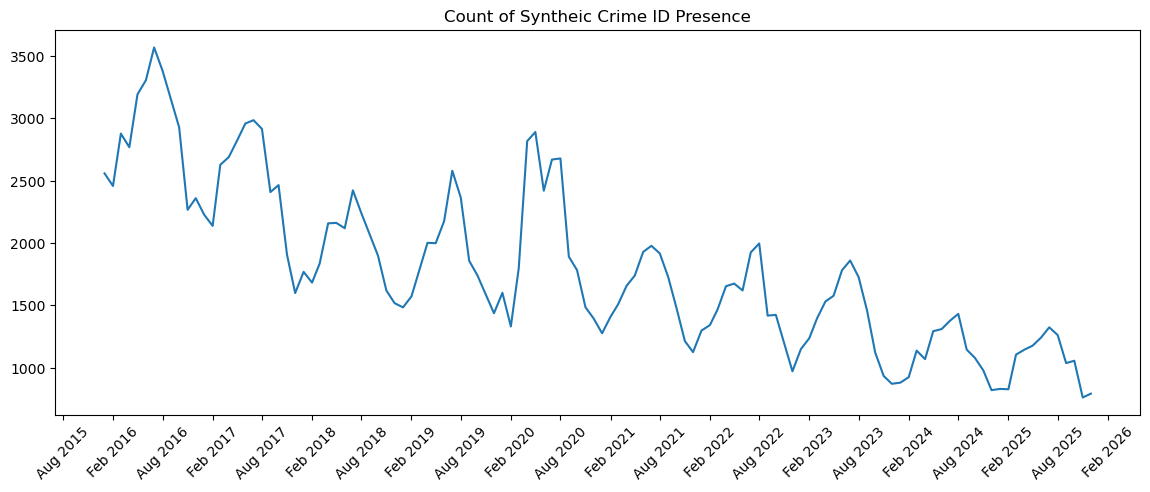

In [23]:
# is this changing over time?
query_syn: str = """SELECT COUNT(*) AS COUNT,
                           "Month"
                    FROM crimetology_NS
                    WHERE starts_with("CRIME ID", 'NO_ID_')
                      AND "Latitude" BETWEEN 51.95 AND 53.00
                      AND "Longitude" BETWEEN 0.30  AND 1.78
                    GROUP BY "Month"
                    ORDER BY "Month";
                 """
df: DataFrame = con.execute(query_syn).df()

quick_time_plot(data_in=df,
                title_in='Count of Syntheic Crime ID Presence',
                row_plot='COUNT')


Question - should this be dropped? Appears to be seasonality and trend in this. It could be some seaonal crime less likely to be assigned a crimeid? OR peaks in systematic demand with data being corrected and updated later in the year?

## Check for NANs

In [24]:
data.isna().sum()

Crime ID          0
Month             0
Longitude         0
Latitude          0
Crime type        0
tasmax         5258
tas            5258
groundfrost    5258
sun            5258
snowLying      5258
tasmin         5258
rainfall       5258
hurs           5258
sfcWind        5258
dtype: int64

Nan data is present in the weather data data. 

In [25]:
# check dropna will work
data.shape[0]-data.dropna().shape[0]

5258

In [26]:
data: DataFrame=data.dropna()

In [27]:
data.isna().sum()

Crime ID       0
Month          0
Longitude      0
Latitude       0
Crime type     0
tasmax         0
tas            0
groundfrost    0
sun            0
snowLying      0
tasmin         0
rainfall       0
hurs           0
sfcWind        0
dtype: int64

## Overall data characterists

In [28]:
data.describe().round(decimals=2)

,Longitude,Latitude,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind
count,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00,1255500.00
mean,1.14,52.44,15.44,11.43,6.50,149.59,0.21,7.42,51.23,79.74,4.39
std,0.40,0.27,5.68,4.90,6.64,70.84,0.71,4.22,29.16,6.56,0.99
min,0.30,51.95,4.81,2.13,0.00,16.01,0.00,-1.64,0.00,60.00,2.54
25%,0.85,52.19,10.26,6.92,0.04,83.21,0.00,3.67,29.35,75.01,3.70
50%,1.19,52.52,15.08,11.29,4.22,156.72,0.00,7.20,48.92,80.11,4.16
75%,1.33,52.64,20.62,15.98,12.27,204.70,0.04,11.46,68.68,85.33,4.84
max,1.76,52.97,27.46,20.69,26.69,328.67,7.65,16.37,253.84,93.97,11.85


_Observations_

Data looks reasonable. 

- snowLying appears heavily skewed, which is not suprising.   
- Max feasible sunshine hours would be ~ 360, so looks reasonable.  
- Tas min, less than zero is suprising for this latitude and altitude. But some very cold winters make this plausible e.g 2021 where ground readings of -7.6ish.    

## Aggregrate by Crime Type

In [29]:
crime_categories_list: list[str] = list(data['Crime type'].drop_duplicates().values)

Collect each data subset and place into a dictionary

In [30]:
data_subsets: dict[str, DataFrame] = {}
for cat in crime_categories_list:
    data_subsets[cat] = data.where(cond=data['Crime type']==cat).dropna()

Plot each crime category frequency over time

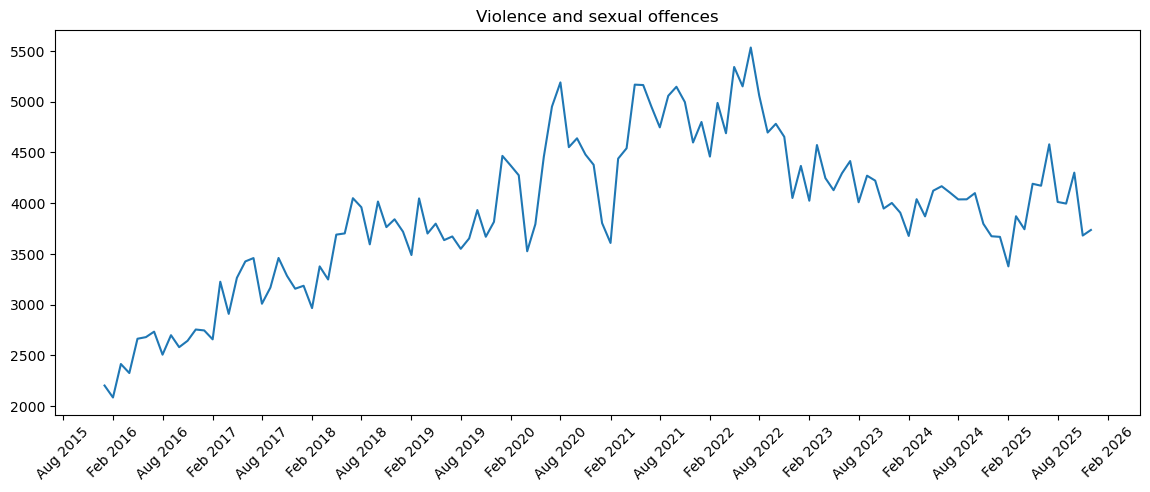

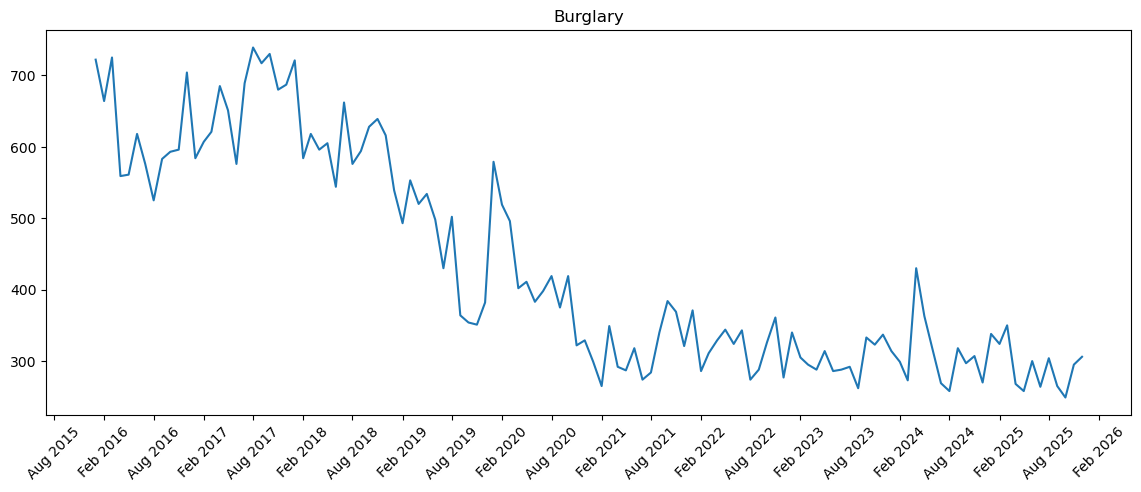

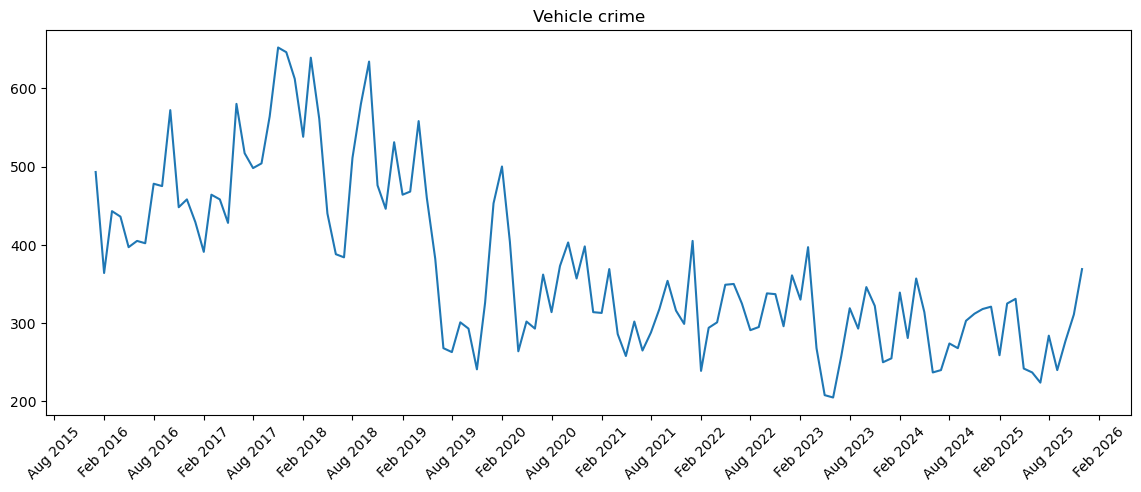

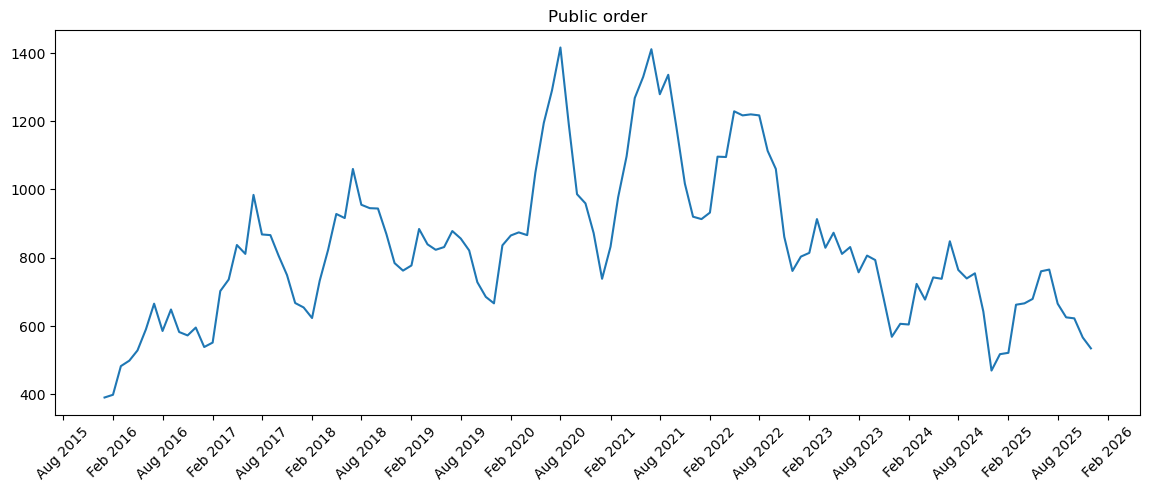

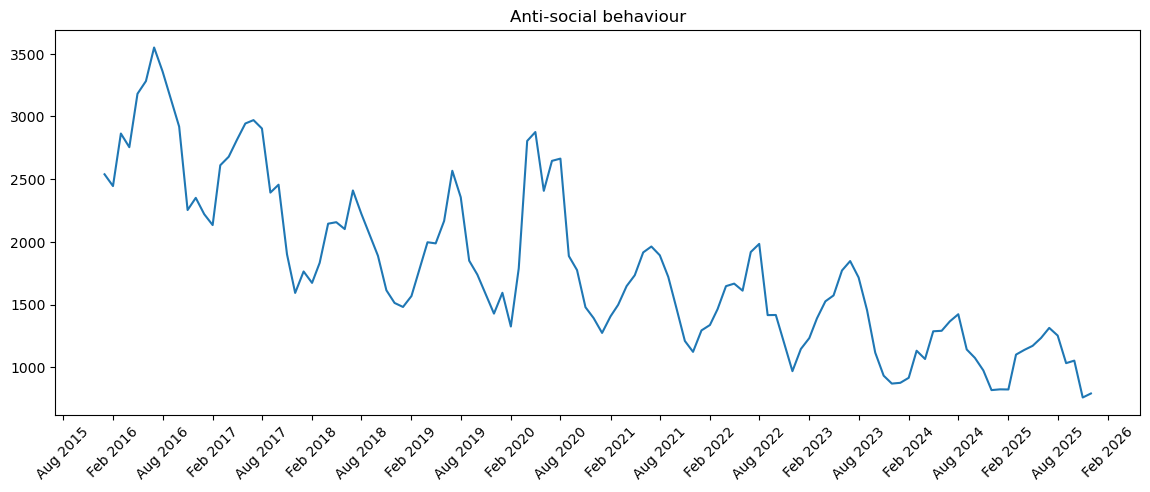

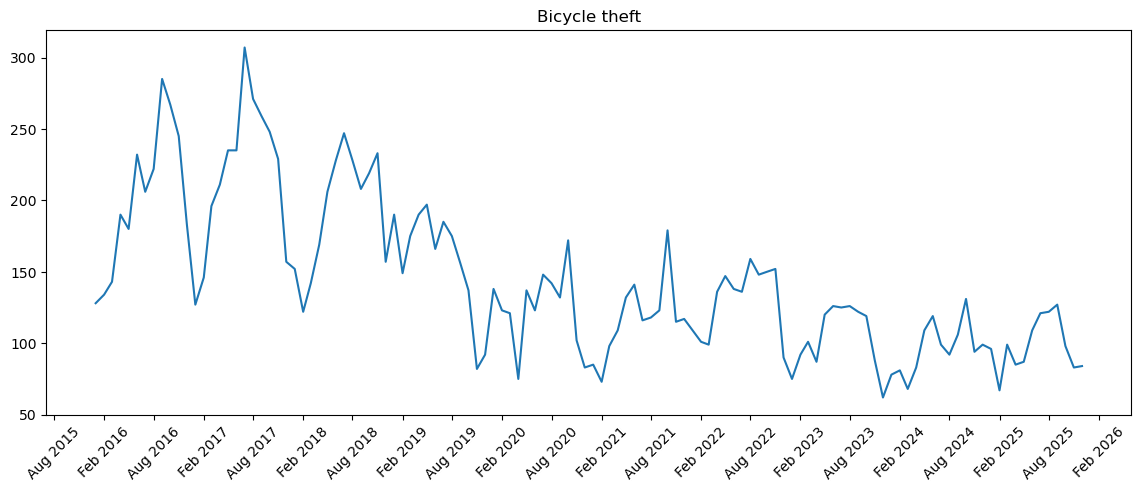

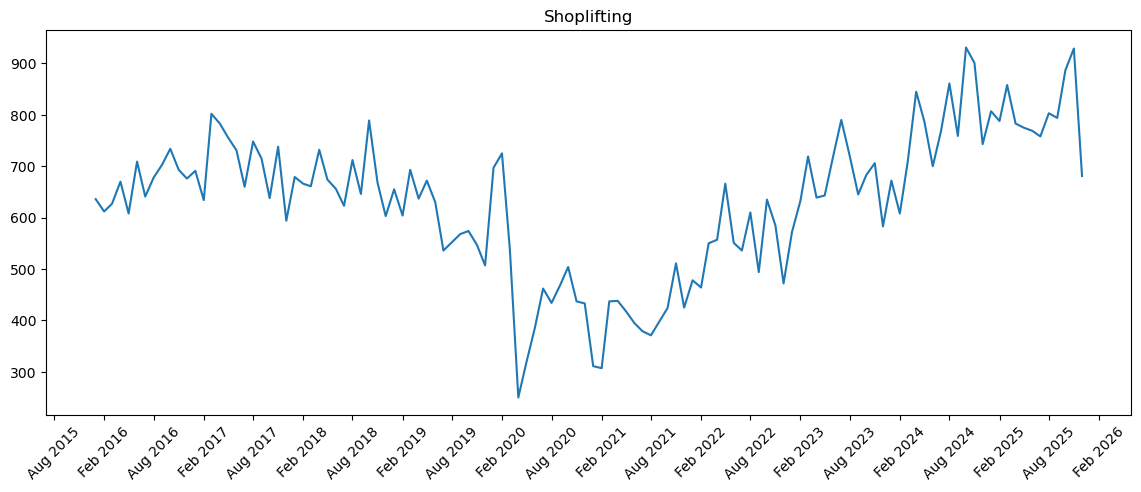

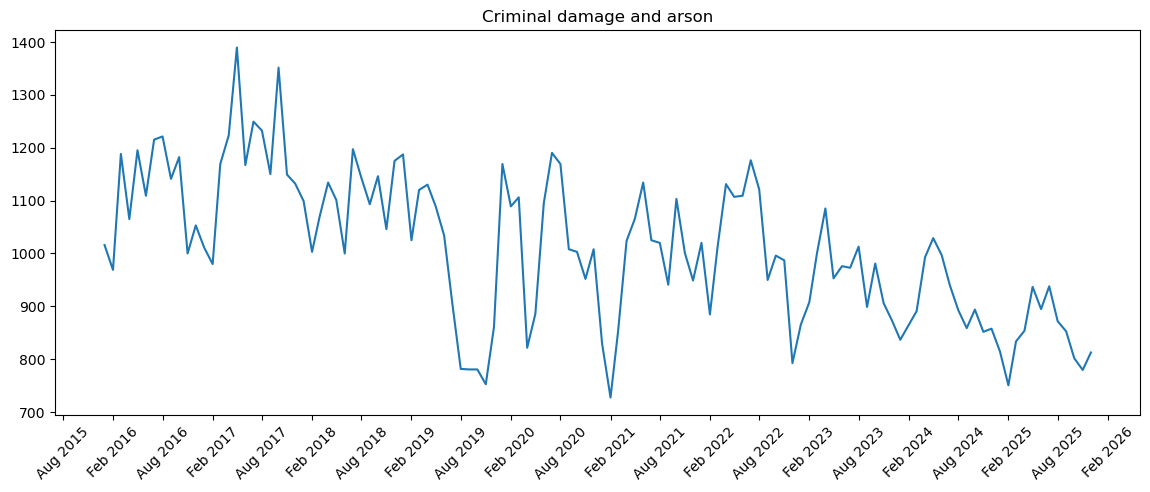

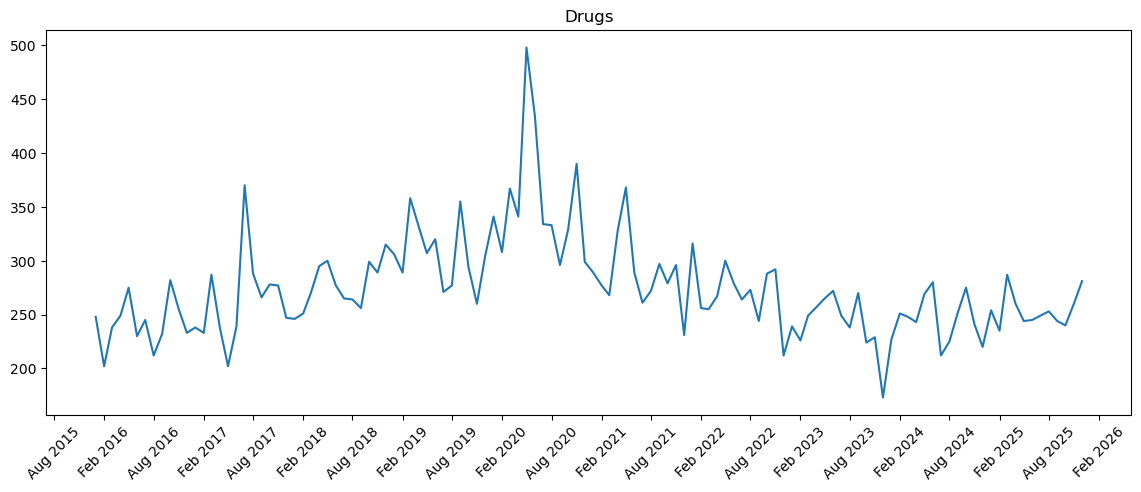

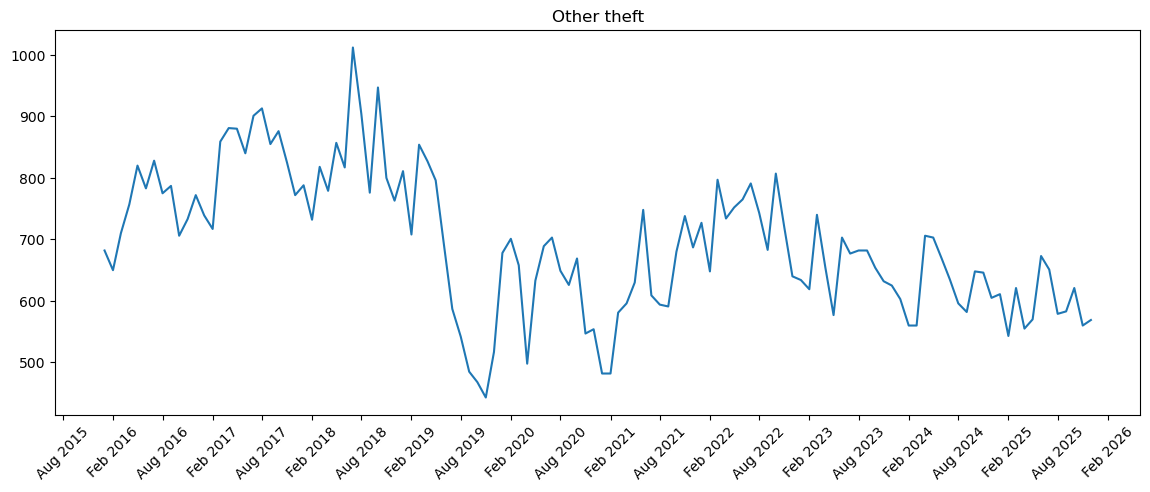

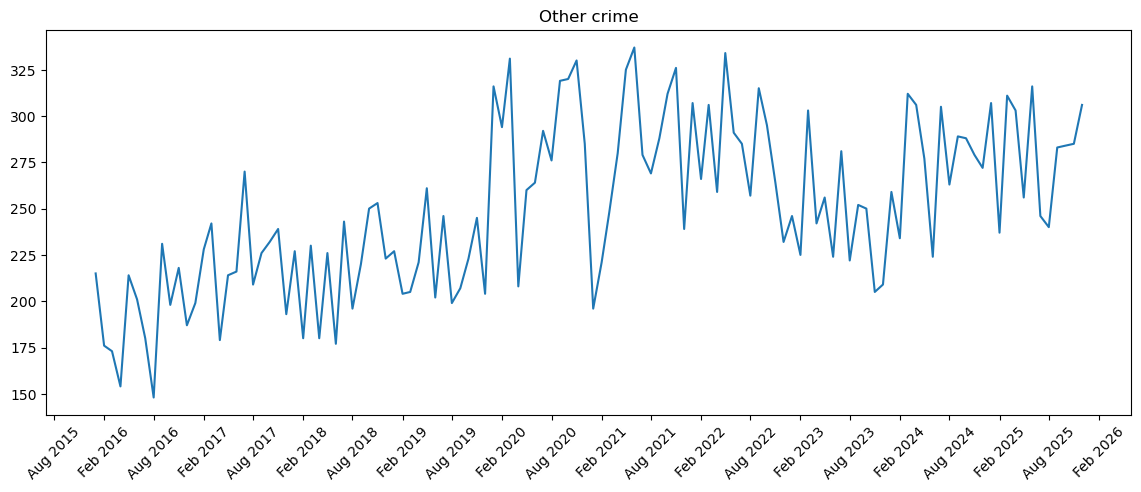

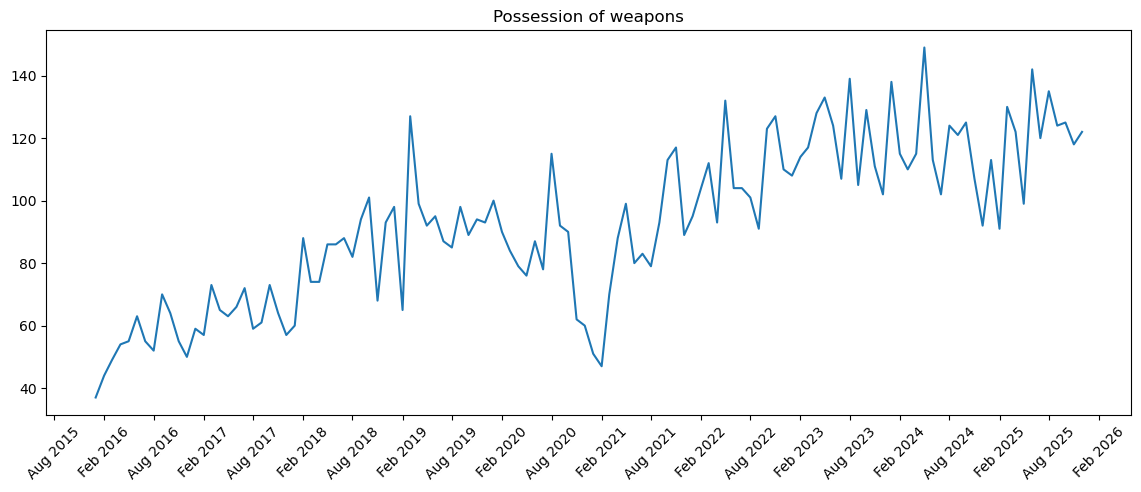

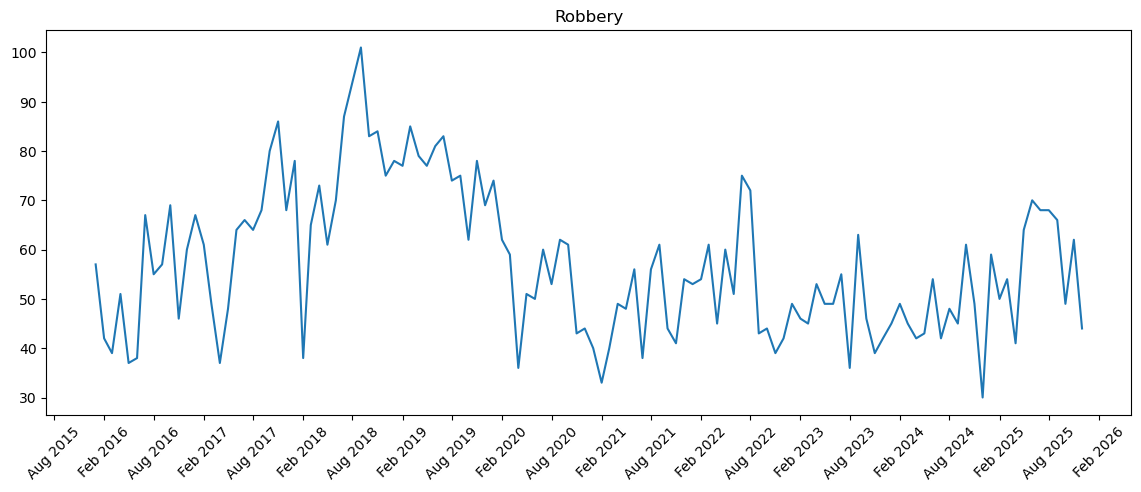

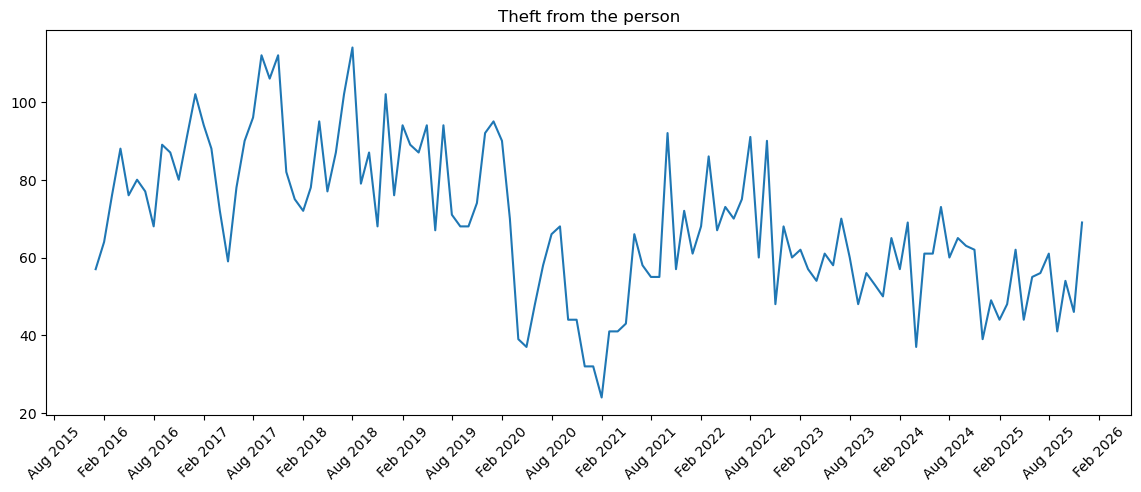

In [31]:
for cat in crime_categories_list:
    df: DataFrame = data_subsets[cat]
    df: DataFrame = df[['Crime ID','Month']].groupby(by='Month').count().reset_index()
    quick_time_plot(data_in=df,
                title_in=cat,
                row_plot='Crime ID')
    plt.show()

In [32]:
plt.close()

_Observations_

- From this it is immediately obvious that covid impacted crime occurance for a number of crime categories (e.g. Theft from the person drops, Drugs increased). March 2020 to Spring 2021. Legitimite question around whether to keep the 2020 to 2021 data or not. Crimes still occurred but general behviour would be notably different from present day drivers. Best course of action would be to run the analysis twice, once on the full dataset and once with the covid time period removed, to see if inclusion of this data impacts the results. 
- The avergae volumes of crime category frequencies are different between crime categories. Will this impact the context label process? Because if higher volume crimes are associated more to one cluster type over the other could this skew the context label results? Will need to keep this in mind during analysis. 
- Data is trended for some crime categories. 

Check minimum and maximum data entries per category to make sure these categorys have been in use for the entrie time span.

In [33]:
data.groupby(by='Crime type').min()['Month']


Crime type
Anti-social behaviour           2016-01
Bicycle theft                   2016-01
Burglary                        2016-01
Criminal damage and arson       2016-01
Drugs                           2016-01
Other crime                     2016-01
Other theft                     2016-01
Possession of weapons           2016-01
Public order                    2016-01
Robbery                         2016-01
Shoplifting                     2016-01
Theft from the person           2016-01
Vehicle crime                   2016-01
Violence and sexual offences    2016-01
Name: Month, dtype: object

In [34]:
data.groupby(by='Crime type').max()['Month']

Crime type
Anti-social behaviour           2025-12
Bicycle theft                   2025-12
Burglary                        2025-12
Criminal damage and arson       2025-12
Drugs                           2025-12
Other crime                     2025-12
Other theft                     2025-12
Possession of weapons           2025-12
Public order                    2025-12
Robbery                         2025-12
Shoplifting                     2025-12
Theft from the person           2025-12
Vehicle crime                   2025-12
Violence and sexual offences    2025-12
Name: Month, dtype: object

In [35]:
md_table = ''
md_table += '### Crime Category Sizes'
md_table += '\n\n'
md_table += '|Category | Entries | Dataset Proportion (%) | \n'
md_table += '| :--- | :--- | :--- |  \n '
for cat in crime_categories_list:
    total_size: int = data.shape[0]
    md_table += f"|{cat}| {data_subsets[cat].shape[0]} | {round(number=((data_subsets[cat].shape[0]/total_size)*100),ndigits=2)} | \n"

Markdown(data=md_table)

### Crime Category Sizes

|Category | Entries | Dataset Proportion (%) | 
| :--- | :--- | :--- |  
 |Violence and sexual offences| 468877 | 37.35 | 
|Burglary| 51860 | 4.13 | 
|Vehicle crime| 44666 | 3.56 | 
|Public order| 99295 | 7.91 | 
|Anti-social behaviour| 204245 | 16.27 | 
|Bicycle theft| 17288 | 1.38 | 
|Shoplifting| 75794 | 6.04 | 
|Criminal damage and arson| 121156 | 9.65 | 
|Drugs| 32921 | 2.62 | 
|Other theft| 83139 | 6.62 | 
|Other crime| 30014 | 2.39 | 
|Possession of weapons| 11120 | 0.89 | 
|Robbery| 6877 | 0.55 | 
|Theft from the person| 8248 | 0.66 | 


## Final Conlusions

Original data has quality issues around event location and weather variable nan presence. These have been overcome via a bounding box on latitude-longitude and dropping nans. 

Data quality looks reasonable post cleaning (the above `data' DataFrame) and will be used for the crimetology workflow. 

Outstanding notable points:
1. covid lockdowns of 2020/2021 impacted crime category occurence and characteristics. 
1. sythetic ID (where no crime URN is submitted upon upload to data archive) is trended downward over time and has seasonality. Duplication of rows more likely towards to start of the time period and certain times of year. This could impact the legitimacy of results; however 16% of the dataset has a synthetic ID.   
1. Crime volume varies by crime type - this may impact the context labelling steps.   

Regarding points one and two - the full data will be retained for now, but covid/sythentic entries should be removed in turn to test the sensitivity of the analysis to these data features. 

In [36]:
data.shape

(1255500, 14)

In [37]:
# save the cleaned data ready for analysis
query_make_clean_table = """CREATE OR REPLACE TABLE crimetology_NS_clean AS
                            SELECT *
                            FROM data
                         """


In [38]:
con.execute(query="BEGIN TRANSACTION;")
con.execute(query=query_make_clean_table)

In [39]:
con.execute(query="COMMIT;")

In [40]:
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [41]:
## rough row count for size comparison
con.execute(query="SELECT table_name, estimated_size from duckdb_tables();").df()

,table_name,estimated_size
0,crimetology_coords_lookup,56204
1,crimetology_NS,1280212
2,crimetology_NS_clean,1255500
3,street_data,93419560


In [42]:
#All looks good
con.close()